# Assignment 3: Numerical Analysis for PDE's (WI3730TU)
### Numerical Solution of the Two-Dimensional Poisson Equation using Finite-Difference and Finite-Volume Methods

**Boundary-Value Problem Details:**
$$
-\nabla\cdot(k\nabla u) = f, \quad (x,y) \in \Omega = (0,10)\times(0,5)
$$
$$
u(x,y) = 0, \quad (x,y) \in \partial\Omega
$$
$$
f(x,y) = \sum_{i=1}^{9}\sum_{j=1}^{4}e^{-\alpha(x-i)^2-\alpha(y-j)^2}, \quad \alpha = 40
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as la
%matplotlib inline

# Domain parameters
LeftX, RightX = 0.0, 10.0
LeftY, RightY = 0.0, 5.0
Lx = RightX - LeftX
Ly = RightY - LeftY

## 📐 Section 1: Explicit Derivations & Discrete Formulations for 2D FDM

### Question 1.1: $\mathcal{O}(h^2)$ Finite-Difference Approximation (1 p)
Throughout the entirety of Section 1, we assume $k=1$ and the BV problem reduces to a negative 2D Laplacian.The central difference approximation for the negative Laplacian $-\Delta u$ at an internal grid node $(x_i, y_j)$ on a uniform but not doubly-uniform mesh ($h_x \neq h_y$) is given by:

$$
-\Delta u(x_i,y_j) = -\frac{\partial^2 u}{\partial x^2} -\frac{\partial^2 u}{\partial y^2}
$$

Using second-order central differences,

$$
-\frac{\partial^2 u}{\partial x^2}(x_i,y_j) \approx \frac{-u_{i-1,j}+2u_{i,j}-u_{i+1,j}}{h_x^2},
$$

and

$$
-\frac{\partial^2 u}{\partial y^2}(x_i,y_j) \approx \frac{-u_{i,j-1}+2u_{i,j}-u_{i,j+1}}{h_y^2}.
$$

Therefore,

$$
-\Delta u_{i,j} \approx \left( \frac{2}{h_x^2} + \frac{2}{h_y^2} \right)u_{i,j} - \frac{1}{h_x^2} \left( u_{i-1,j}+u_{i+1,j} \right) - \frac{1}{h_y^2} \left( u_{i,j-1}+u_{i,j+1} \right)

$$

with truncation error

$$
-\Delta u_{i,j} = \left( \frac{2}{h_x^2} + \frac{2}{h_y^2} \right)u_{i,j} - \frac{u_{i-1,j}+u_{i+1,j}}{h_x^2} - \frac{u_{i,j-1}+u_{i,j+1}}{h_y^2} + \mathcal{O}(h_x^2+h_y^2).
$$

### Question 1.2: Explicit Discrete Equations on a $4 \times 4$ Mesh (2 p)
Given $N_x = 4, N_y = 4 \implies h_x = \frac{10}{4} = 2.5$ and $h_y = \frac{5}{4} = 1.25$. With homogeneous Dirichlet boundary conditions ($u = 0$ on $\partial\Omega$), the boundary unknowns are eliminated, leaving 9 inner unknowns ordered lexicographically:
$$
\mathbf{u} = [u_{1,1}, u_{2,1}, u_{3,1}, u_{1,2}, u_{2,2}, u_{3,2}, u_{1,3}, u_{2,3}, u_{3,3}]^T
$$

The resulting algebraic equations at each interior point evaluate to:

$$
\begin{aligned}

\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{1,1}
-\frac{1}{h_x^2}u_{2,1}
-\frac{1}{h_y^2}u_{1,2}
&= f_{1,1}
\\

-\frac{1}{h_x^2}u_{1,1}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{2,1}
-\frac{1}{h_x^2}u_{3,1}
-\frac{1}{h_y^2}u_{2,2}
&= f_{2,1}
\\

-\frac{1}{h_x^2}u_{2,1}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{3,1}
-\frac{1}{h_y^2}u_{3,2}
&= f_{3,1}
\\[1mm]

-\frac{1}{h_y^2}u_{1,1}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{1,2}
-\frac{1}{h_x^2}u_{2,2}
-\frac{1}{h_y^2}u_{1,3}
&= f_{1,2}
\\

-\frac{1}{h_y^2}u_{2,1}
-\frac{1}{h_x^2}u_{1,2}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{2,2}
-\frac{1}{h_x^2}u_{3,2}
-\frac{1}{h_y^2}u_{2,3}
&= f_{2,2}
\\

-\frac{1}{h_y^2}u_{3,1}
-\frac{1}{h_x^2}u_{2,2}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{3,2}
-\frac{1}{h_y^2}u_{3,3}
&= f_{3,2}
\\[1mm]

-\frac{1}{h_y^2}u_{1,2}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{1,3}
-\frac{1}{h_x^2}u_{2,3}
&= f_{1,3}
\\

-\frac{1}{h_y^2}u_{2,2}
-\frac{1}{h_x^2}u_{1,3}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{2,3}
-\frac{1}{h_x^2}u_{3,3}
&= f_{2,3}
\\

-\frac{1}{h_y^2}u_{3,2}
-\frac{1}{h_x^2}u_{2,3}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{3,3}
&= f_{3,3}

\end{aligned}
$$


Substituting the step coefficients:
$$
\frac{1}{h_x^2} = \frac{1}{2.5^2} = 0.16, \quad \frac{1}{h_y^2} = \frac{1}{1.25^2} = 0.64, \quad \frac{2}{h_x^2} + \frac{2}{h_y^2} = 1.6
$$

The system matrix is
$$
A=
\begin{bmatrix}
1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0 & 0\\
-0.16 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0\\
0 & -0.16 & 1.6 & 0 & 0 & -0.64 & 0 & 0 & 0\\
-0.64 & 0 & 0 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0\\
0 & -0.64 & 0 & -0.16 & 1.6 & -0.16 & 0 & -0.64 & 0\\
0 & 0 & -0.64 & 0 & -0.16 & 1.6 & 0 & 0 & -0.64\\
0 & 0 & 0 & -0.64 & 0 & 0 & 1.6 & -0.16 & 0\\
0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6 & -0.16\\
0 & 0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6
\end{bmatrix}.
$$

### Question 1.3: Kronecker Product Proof ($A = I_y \otimes L_{xx} + L_{yy} \otimes I_x$) (4 p)
Under lexicographic ordering, the 2D stencil can be decoupled into directional 1D operations. For a 1D problem with $N=4$, the negative 1D Laplacians $L_{xx}$ and $L_{yy}$ are generated from $D_{x}^TD_{x}$ and $D_{y}^{T}D_{y}$ as follows.

We now show that the matrix obtained above can be written as $A=I_y\otimes L_{xx}+L_{yy}\otimes I_x.$

Because there are three interior grid points in each coordinate direction, $ I_x=I_y=I_3, $ where

$$
I_x=I_y=
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix}
$$

### First-difference matrices

For the \(x\)-direction, define

$$
D_x=
\frac{1}{h_x}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix}
$$

The four rows represent the differences between the boundary and interior values and between neighbouring interior values.

Its transpose is

$$
D_x^T=
\frac{1}{h_x}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}
$$

Consequently, $ L_{xx}=D_x^TD_x. $

Thus,

$$
L_{xx} =
\frac{1}{h_x^2}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix} =
\frac{1}{h_x^2}
\begin{bmatrix}
2&-1&0\\
-1&2&-1\\
0&-1&2
\end{bmatrix}.
$$

Since $ \frac{1}{h_x^2}=0.16, $ we obtain

$$
L_{xx}
=
\begin{bmatrix}
0.32&-0.16&0\\
-0.16&0.32&-0.16\\
0&-0.16&0.32
\end{bmatrix}.
$$

Likewise,

$$
D_y=
\frac{1}{h_y}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix},
$$

so

$$
D_y^T=
\frac{1}{h_y}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}.
$$

Therefore, $ L_{yy}=D_y^TD_y. $

This becomes

$$
L_{yy}
=
\frac{1}{h_y^2}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix}. =
\frac{1}{h_y^2}
\begin{bmatrix}
2&-1&0\\
-1&2&-1\\
0&-1&2
\end{bmatrix}.
$$

Since $ \frac{1}{h_y^2}=0.64, $ this becomes

$$
L_{yy}
=
\begin{bmatrix}
1.28&-0.64&0\\
-0.64&1.28&-0.64\\
0&-0.64&1.28
\end{bmatrix}.
$$

### \(x\)-direction contribution

The Kronecker product $ I_y\otimes L_{xx} $ places a copy of $L_{xx}$ on the diagonal for each horizontal row of interior grid points:

$$
I_y\otimes L_{xx}
=
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix}
\otimes
\begin{bmatrix}
0.32&-0.16&0\\
-0.16&0.32&-0.16\\
0&-0.16&0.32
\end{bmatrix} =
\begin{bmatrix}
0.32&-0.16&0&0&0&0&0&0&0\\
-0.16&0.32&-0.16&0&0&0&0&0&0\\
0&-0.16&0.32&0&0&0&0&0&0\\
0&0&0&0.32&-0.16&0&0&0&0\\
0&0&0&-0.16&0.32&-0.16&0&0&0\\
0&0&0&0&-0.16&0.32&0&0&0\\
0&0&0&0&0&0&0.32&-0.16&0\\
0&0&0&0&0&0&-0.16&0.32&-0.16\\
0&0&0&0&0&0&0&-0.16&0.32
\end{bmatrix}
$$

This matrix couples grid points that are neighbours in the \(x\)-direction.

### \(y\)-direction contribution

Similarly,

$$
L_{yy}\otimes I_x
=
\begin{bmatrix}
1.28&-0.64&0\\
-0.64&1.28&-0.64\\
0&-0.64&1.28
\end{bmatrix}
\otimes
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix} =
\begin{bmatrix}
1.28&0&0&-0.64&0&0&0&0&0\\
0&1.28&0&0&-0.64&0&0&0&0\\
0&0&1.28&0&0&-0.64&0&0&0\\
-0.64&0&0&1.28&0&0&-0.64&0&0\\
0&-0.64&0&0&1.28&0&0&-0.64&0\\
0&0&-0.64&0&0&1.28&0&0&-0.64\\
0&0&0&-0.64&0&0&1.28&0&0\\
0&0&0&0&-0.64&0&0&1.28&0\\
0&0&0&0&0&-0.64&0&0&1.28
\end{bmatrix}
$$

This matrix couples grid points that are neighbours in the \(y\)-direction.

### Summation

The complete two-dimensional operator is therefore $$ A = I_y\otimes L_{xx} + L_{yy}\otimes I_x. $$

Adding the two matrices gives

$$
A=\begin{bmatrix}
1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0 & 0\\
-0.16 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0\\
0 & -0.16 & 1.6 & 0 & 0 & -0.64 & 0 & 0 & 0\\
-0.64 & 0 & 0 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0\\
0 & -0.64 & 0 & -0.16 & 1.6 & -0.16 & 0 & -0.64 & 0\\
0 & 0 & -0.64 & 0 & -0.16 & 1.6 & 0 & 0 & -0.64\\
0 & 0 & 0 & -0.64 & 0 & 0 & 1.6 & -0.16 & 0\\
0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6 & -0.16\\
0 & 0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6
\end{bmatrix}.$$

This is exactly the matrix obtained by explicitly writing out the nine finite-difference equations in Question 1.2. Hence, $A=I_y\otimes L_{xx}+L_{yy}\otimes I_x.$

The interpretation is straightforward: $(I_y\otimes L_{xx})$ applies the one-dimensional Laplacian independently along every horizontal row, while $(L_{yy}\otimes I_x)$ couples the corresponding points of neighbouring horizontal rows. Adding these two directional contributions produces the complete two-dimensional five-point Laplacian.


## 📐 Section 2: Discrete Formulation for 2D FVM (3 p)

For a uniform grid with grid steps $h_{x}$ and $h_{y}$ the inner point vertex-centered FV equation averaged over the elementary cell is:

For the two-dimensional finite-volume method, consider the steady diffusion equation

$$
-\nabla\cdot(k\nabla u)=f.
$$

In the vertex-centred finite-volume method, the unknown $u_{i,j}$ is associated with the grid vertex $(x_i,y_j)$, and a rectangular control volume $V_{i,j}$ is constructed around this vertex. For a uniform Cartesian grid with spacings $h_x$ and $h_y$, the control volume extends $h_x/2$ in the $x$-direction and $h_y/2$ in the $y$-direction, so that $ |V_{i,j}|=h_xh_y.$

The finite-volume derivation begins by integrating the PDE over the complete control volume,

$$
\iint_{V_{i,j}}-\nabla\cdot(k\nabla u)\,dV
=
\iint_{V_{i,j}}f\,dV
$$

Applying the divergence theorem converts the volume integral into a boundary-flux integral,

$$
\int_{\partial V_{i,j}}
-k\nabla u\cdot\mathbf n\,d\Gamma
=
\iint_{V_{i,j}}f\,dV
$$

Equivalently,

$$
\int_{\partial V_{i,j}}
-k\frac{\partial u}{\partial n}\,d\Gamma
=
\iint_{V_{i,j}}f\,dV
$$

For an interior control volume on a uniform grid, the source integral can be approximated using the midpoint rule,

$$
\int_{V_{i,j}}f\,dV
\approx
f_{i,j}h_xh_y
$$

The boundary integral consists of the fluxes through the west, east, south, and north faces. The outward normal vectors are

$$
\mathbf n_W=
\begin{bmatrix}
-1\\
0
\end{bmatrix}
\qquad
\mathbf n_E=
\begin{bmatrix}
1\\
0
\end{bmatrix}
$$

$$
\mathbf n_S=
\begin{bmatrix}
0\\
-1
\end{bmatrix}
\qquad
\mathbf n_N=
\begin{bmatrix}
0\\
1
\end{bmatrix}
$$

Therefore,

$$
\frac{\partial u}{\partial n}\bigg|_{\Gamma_W}
=
-\frac{\partial u}{\partial x}
\qquad
\frac{\partial u}{\partial n}\bigg|_{\Gamma_E}
=
\frac{\partial u}{\partial x}
$$

and

$$
\frac{\partial u}{\partial n}\bigg|_{\Gamma_S}
=
-\frac{\partial u}{\partial y}
\qquad
\frac{\partial u}{\partial n}\bigg|_{\Gamma_N}
=
\frac{\partial u}{\partial y}
$$

Hence the integrated balance becomes

$$
\int_{\Gamma_W}k\frac{\partial u}{\partial x}dy
-
\int_{\Gamma_E}k\frac{\partial u}{\partial x}dy
+
\int_{\Gamma_S}k\frac{\partial u}{\partial y}dx
-
\int_{\Gamma_N}k\frac{\partial u}{\partial y}dx
=
\int_{V_{i,j}}f\,dV
$$

The derivative at each face is approximated using the two neighbouring vertex values. At the east face,

$$
\left.
\frac{\partial u}{\partial x}
\right|_{i+\frac12,j}
\approx
\frac{u_{i+1,j}-u_{i,j}}{h_x}
$$

while at the west face,

$$
\left.
\frac{\partial u}{\partial x}
\right|_{i-\frac12,j}
\approx
\frac{u_{i,j}-u_{i-1,j}}{h_x}
$$

Similarly, in the $y$-direction,

$$
\left.
\frac{\partial u}{\partial y}
\right|_{i,j+\frac12}
\approx
\frac{u_{i,j+1}-u_{i,j}}{h_y}
$$

and

$$
\left.
\frac{\partial u}{\partial y}
\right|_{i,j-\frac12}
\approx
\frac{u_{i,j}-u_{i,j-1}}{h_y}.
$$

The diffusion coefficient is evaluated at the face midpoints,

$$
k_{i+\frac12,j}
=
k\left(x_i+\frac{h_x}{2},y_j\right),
\qquad
k_{i-\frac12,j}
=
k\left(x_i-\frac{h_x}{2},y_j\right),
$$

and

$$
k_{i,j+\frac12}
=
k\left(x_i,y_j+\frac{h_y}{2}\right),
\qquad
k_{i,j-\frac12}
=
k\left(x_i,y_j-\frac{h_y}{2}\right).
$$

The four face contributions are therefore approximated by

$$
\int_{\Gamma_W}k\frac{\partial u}{\partial x}\,dy
\approx
h_y k_{i-\frac12,j}
\frac{u_{i,j}-u_{i-1,j}}{h_x},
$$

$$
-\int_{\Gamma_E}k\frac{\partial u}{\partial x}\,dy
\approx
-h_y k_{i+\frac12,j}
\frac{u_{i+1,j}-u_{i,j}}{h_x},
$$

$$
\int_{\Gamma_S}k\frac{\partial u}{\partial y}\,dx
\approx
h_x k_{i,j-\frac12}
\frac{u_{i,j}-u_{i,j-1}}{h_y},
$$

and

$$
-\int_{\Gamma_N}k\frac{\partial u}{\partial y}\,dx
\approx
-h_x k_{i,j+\frac12}
\frac{u_{i,j+1}-u_{i,j}}{h_y}.
$$

Substituting these approximations into the integrated conservation equation gives

$$
h_y k_{i-\frac12,j}
\frac{u_{i,j}-u_{i-1,j}}{h_x}
-
h_y k_{i+\frac12,j}
\frac{u_{i+1,j}-u_{i,j}}{h_x}
+
h_x k_{i,j-\frac12}
\frac{u_{i,j}-u_{i,j-1}}{h_y}
-
h_x k_{i,j+\frac12}
\frac{u_{i,j+1}-u_{i,j}}{h_y}
=
h_xh_y f_{i,j}.
$$

Dividing by the control-volume area $h_xh_y$ gives

$$
-\frac{k_{i-\frac12,j}}{h_x^2}u_{i-1,j}
-\frac{k_{i,j-\frac12}}{h_y^2}u_{i,j-1}
+
\left(
\frac{k_{i-\frac12,j}+k_{i+\frac12,j}}{h_x^2}
+
\frac{k_{i,j-\frac12}+k_{i,j+\frac12}}{h_y^2}
\right)u_{i,j}
-\frac{k_{i+\frac12,j}}{h_x^2}u_{i+1,j}
-\frac{k_{i,j+\frac12}}{h_y^2}u_{i,j+1}
=
f_{i,j}.
$$

For the constant-coefficient case $k=1$, this reduces to

$$
\frac{2u_{i,j}-u_{i-1,j}-u_{i+1,j}}{h_x^2}
+
\frac{2u_{i,j}-u_{i,j-1}-u_{i,j+1}}{h_y^2}
=
f_{i,j}.
$$

Equivalently,

$$
\left(
\frac{2}{h_x^2}
+
\frac{2}{h_y^2}
\right)u_{i,j}
-
\frac{u_{i-1,j}+u_{i+1,j}}{h_x^2}
-
\frac{u_{i,j-1}+u_{i,j+1}}{h_y^2}
=
f_{i,j}.
$$

For $N_x=4$ and $N_y=4$, the grid indices run from $0$ to $4$. The indices $0$ and $4$ correspond to boundary vertices, so the interior points satisfy $ i=1,\ldots,N_x-1=3, $ and $ j=1,\ldots,N_y-1=3. $

## 📊 Section 3: Coding System Assembly Functions

### Question 3.1: Complete the code to assemble the sparse matrices $D_{x}$ or $D_{y}$ and the complete FDM Laplacian using the Kronecker product formula (4 p)

In [8]:
def Diff1(N):
    diagonals = [np.ones(N-1), np.ones(N-1)] #REPLACE THIS
    locations = [0, 1] #REPLACE THIS
    return sp.diags(diagonals, locations, shape=(N, N-1))

def FDLaplacian2D(Nx, Ny, dx, dy):
    Dx = Diff1(Nx) / dx
    Lxx = sp.eye(Nx-1) #REPLACE THIS
    Dy = Diff1(Ny) / dy
    Lyy = sp.eye(Ny-1) #REPLACE THIS
    Ix = sp.eye(Nx-1)
    Iy = sp.eye(Ny-1)
    return sp.kron(Iy, Lxx) + sp.kron(Lyy, Ix)

In [17]:
# you can test your assembly function as follows
Nx = 4
Ny = 4
dx = Lx/Nx
dy = Ny/Ny
print(FDLaplacian2D(Nx,Ny,dx,dy).todense())

[[2. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 2.]]


### Question 3.2: Complete the code to assemble the sparse matrix of the FVM Laplacian (6 p)

In [13]:
def sourcefunc(x, y):
    Nsx = int(Lx) - 1
    Nsy = int(Ly) - 1
    a = 40
    F = 0.0
    for ii in range(Nsx):
        for jj in range(Nsy):
            F = F + np.exp(-a*(x-(ii+1))**2 - a*(y-(jj+1))**2)
    return F

def coeffK1(x, y):
    return np.ones(np.shape(x))

def coeffK2(x, y):
    return 1.0 + 0.1*(x + y + x*y)

In [15]:
def create2DLFVM(Lx, Ly, Nx, Ny, coeffFun):
    dx, dy = Lx/Nx, Ly/Ny
    n_cells = (Nx-1)*(Ny-1)
    d0 = np.zeros(n_cells)
    d1plus = np.zeros(n_cells-1)
    d1minus = np.zeros(n_cells-1)
    d2plus = np.zeros(n_cells-(Nx-1))
    d2minus = np.zeros(n_cells-(Nx-1))
    
    n0 = 0
    for jj in range(Ny-1):
        yj = dy + jj*dy
        for ii in range(Nx-1):
            xi = dx + ii*dx
            # YOR CODE HERE
            
    return sp.diags([d2minus, d1minus, d0, d1plus, d2plus], [-(Nx-1), -1, 0, 1, (Nx-1)], shape=(n_cells, n_cells), format='csc')

## 📊 Section 4: Tests, Simulations, Visualizations

### Question 4.1: Assemble, print, and visualize FDM system matrix on a small grid (1 p)

Test FDM matrix A =
 [[2. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 2.]]


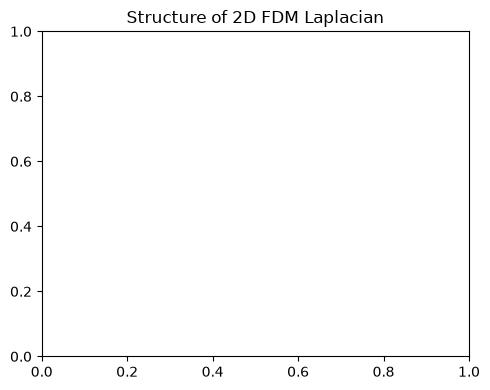

In [20]:
Nx, Ny = 4, 4
dx, dy = Lx/Nx, Ly/Ny
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j]
A_fdm_small = FDLaplacian2D(Nx, Ny, dx, dy)
print('Test FDM matrix A =\n',A_fdm_small.todense())

plt.figure(figsize=(5, 4))
# YOUR CODE HERE - use plt.spy() with round green markers
plt.title('Structure of 2D FDM Laplacian')
plt.tight_layout()
plt.show()

### Question 4.2: Assemble, print, and test the symmetry of the FVM system matrix on a small grid (1 p)

In [29]:
Nx, Ny = 4, 4
dx, dy = Lx/Nx, Ly/Ny
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j]
A_fvm_small = create2DLFVM(Lx, Ly, Nx, Ny, coeffK2)
print('Test FVM matrix A =\n',A_fvm_small.todense())
print('Symmetry error =', ) #REPLACE THIS

Test FVM matrix A =
 [[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Symmetry error =


### Question 4.3 Assemble and compute FDM and FVM solutions on a finer grid (3 p)

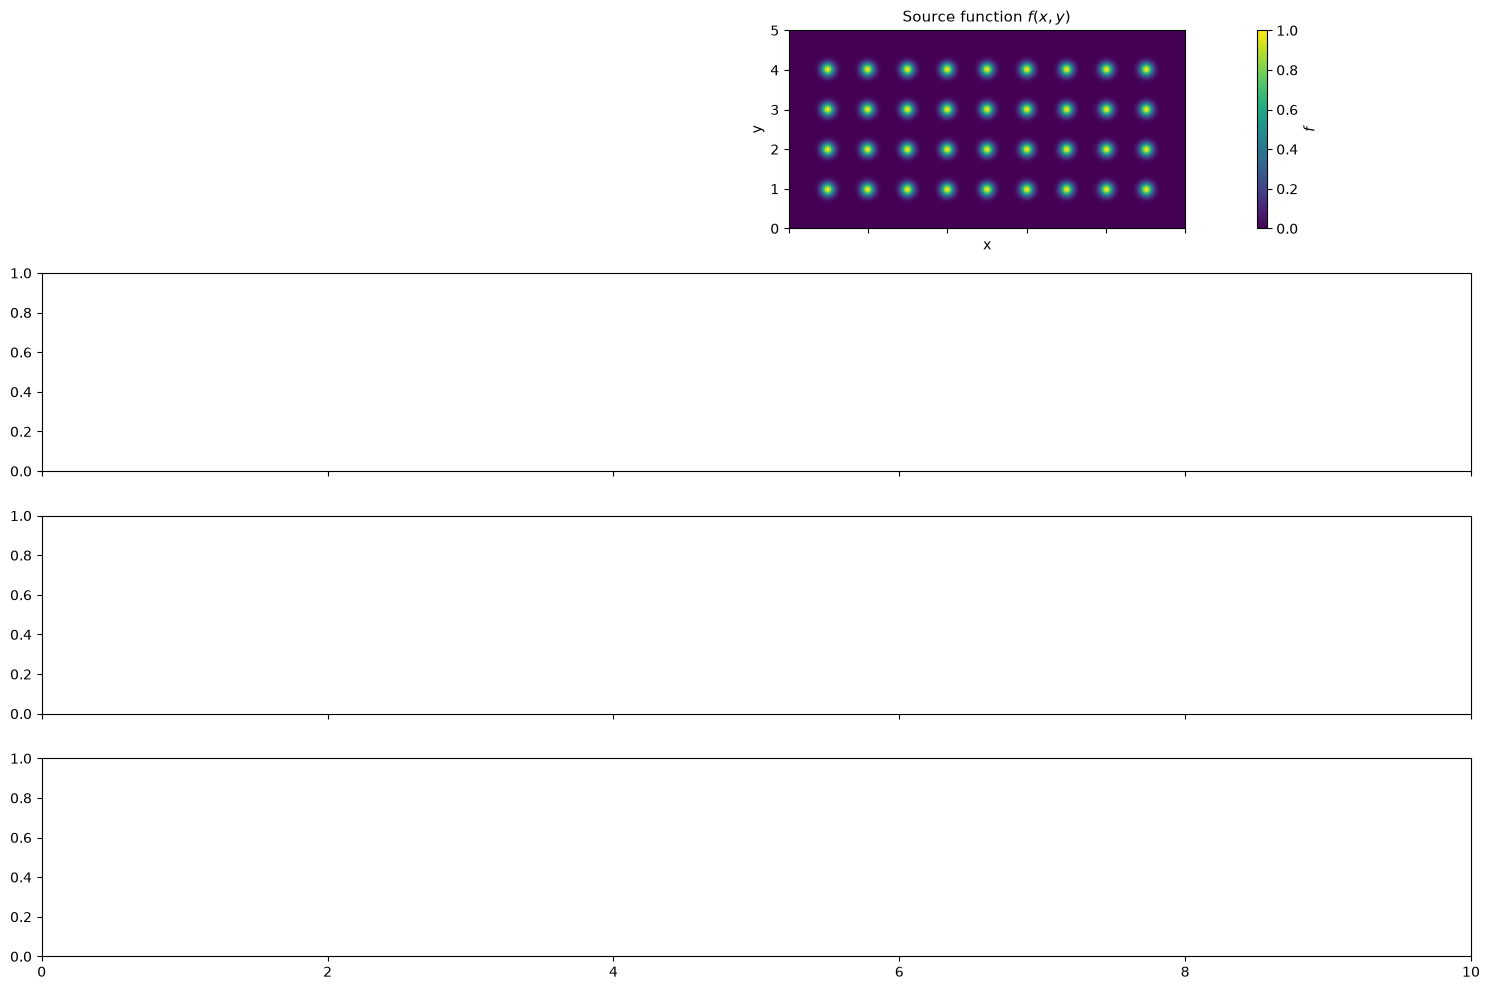

In [21]:
Nx, Ny = 200, 100
dx, dy = Lx/Nx, Ly/Ny
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j]
f = sourcefunc(x, y)

#YOUR CODE HERE

# 3. Visualizations as 2D images
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

im0 = axes[0].imshow(f.transpose(), extent=[0, Lx, 0, Ly], origin='lower', cmap='viridis')
axes[0].set_title('Source function $f(x,y)$', fontsize=11)
fig.colorbar(im0, ax=axes[0], label='$f$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

#YOUR CODE HERE

plt.tight_layout()
plt.show()

### Question 4.4: Check RMSE between FDM and FVM solutions (1 p)

In [25]:
print('RMSE between FDM and FVM solutions =', ) #REPLACE THIS

RMSE between FDM and FVM solutions =


### Question 4.5: Horizontal cross-section profiling plot of FVM slutions (1 p)

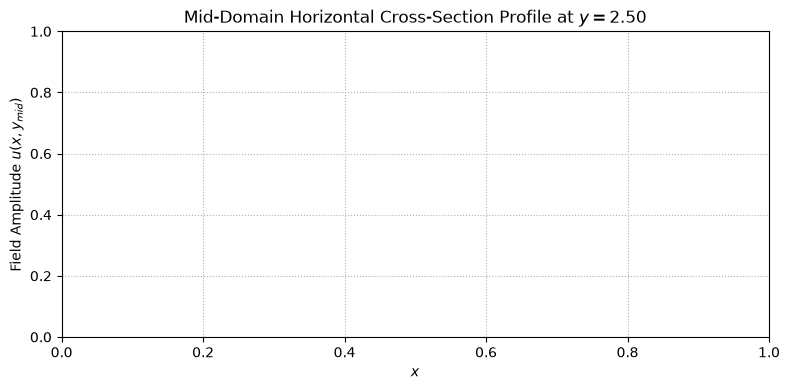

In [28]:
plt.figure(figsize=(8, 4))
# YOUR CODE HERE
plt.title(f'Mid-Domain Horizontal Cross-Section Profile at $y = {Ly/2:.2f}$', fontsize=12)
plt.xlabel('$x$')
plt.ylabel('Field Amplitude $u(x, y_{mid})$')
plt.grid(True, linestyle=':')
#plt.legend() #UNCOMMENT
plt.tight_layout()
plt.show()

### 📝 Section 5: Analysis & Discussion (4 p)

5.1 According to the Maximum Principle, the solution for $k(x,y)=1$ is expected to...

5.2 Solutions obtained with the FD and FV Methods for $k(x,y)=1$ are expected to...

5.3 At the boundary, the solutions are expected to...

5.4 With the inhomogeneous $k(x,y)$, the solution is expected to...